Regressione SVM 

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [9]:
data=load_diabetes()
X=data.data
y=data.target

In [10]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

alleniamo 3 tipo di regressori con SVM
kernel lineare
kernel non lineare cambiando il valore di epsilong
poi calcolia il min_quare_error e r2_score

kernel lineare

In [ ]:
svr_linear=SVR(kernel="linear",C=1.0,epsilon=5.0)
svr_linear.fit(X_scaled,y)
y_pred_linear=svr_linear.predict(X_scaled)
mse_linear=mean_squared_error(y,y_pred_linear)
r2_linear=r2_score(y,y_pred_linear)

kernel gaussiano

il parametro epsilon è molto importante perchè definisce zona di tolleranza attorno alla previsione.
Immagina una fascia attorno alla retta: tutto quello che cade dentro non è considerato errore.

In [15]:
svr_rbf_narrow=SVR(kernel="rbf",C=1.5,epsilon=5.0)
svr_rbf_narrow.fit(X_scaled,y)
y_pred_narrow=svr_rbf_narrow.predict(X_scaled)
mse_narrow=mean_squared_error(y,y_pred_narrow)
r2_narrow=r2_score(y,y_pred_narrow)

kernel gaussiano ma con parametro epsilong maggiore

In [17]:
svr_rbf_wide=SVR(kernel="rbf",C=1.5,epsilon=20.0)
svr_rbf_wide.fit(X_scaled,y)
y_pred_wide=svr_rbf_wide.predict(X_scaled)
mse_wide=mean_squared_error(y,y_pred_wide)
r2_wide=r2_score(y,y_pred_wide)

In [18]:
print(f"LINEAR")
print(f"\tMSE: {mse_linear}\t R2:{r2_linear}")
print(f"RBF (eps=5)")
print(f"\tMSE: {mse_narrow}\t R2:{r2_narrow}")
print(f"RBF (eps=20)")
print(f"\tMSE: {mse_wide}\t R2:{r2_wide}")

LINEAR
	MSE: 2902.775362214766	 R2:0.5104836918964171
RBF (eps=5)
	MSE: 4234.217036465413	 R2:0.2859529130706153
RBF (eps=20)
	MSE: 4239.842004843539	 R2:0.28500433338046716


Usando il kernel linear si ha un mse minore rispetto gaussiano e r2 è molto più alto 0.5 che di per se non è un valore alto ma rispetto agli altri è sicuramente migliore
Anche l MSE lineare si adatta meglio agli altri ed è poco meno della metà rispetto ai quelli gaussiani

Effetuiamo il plot di tutti e 3 i modelli sugli stessi dati.
Devo rendere il dataset bidimensionale, c'è una feature che bodymaxindex che è strettamente legato ai valori del diabiete. pertanto prendiamo questa faeature

In [25]:
feature_index=2
#ordiniamo i valori di questa feature dal più piccolo al più grande, altrimenti sull'asse x avrei una linea con punto collegati con ordine casuale.
sort_idx=X_scaled[:,feature_index].argsort()
X_plot=X_scaled[sort_idx,feature_index]

In [26]:
#stesso ordinamento anche per le label predette
y_pred_narrow_plot=y_pred_narrow[sort_idx]
y_pred_wide_plot=y_pred_wide[sort_idx]
y_pred_linear_plot=y_pred_linear[sort_idx]

Creaiamo il plot

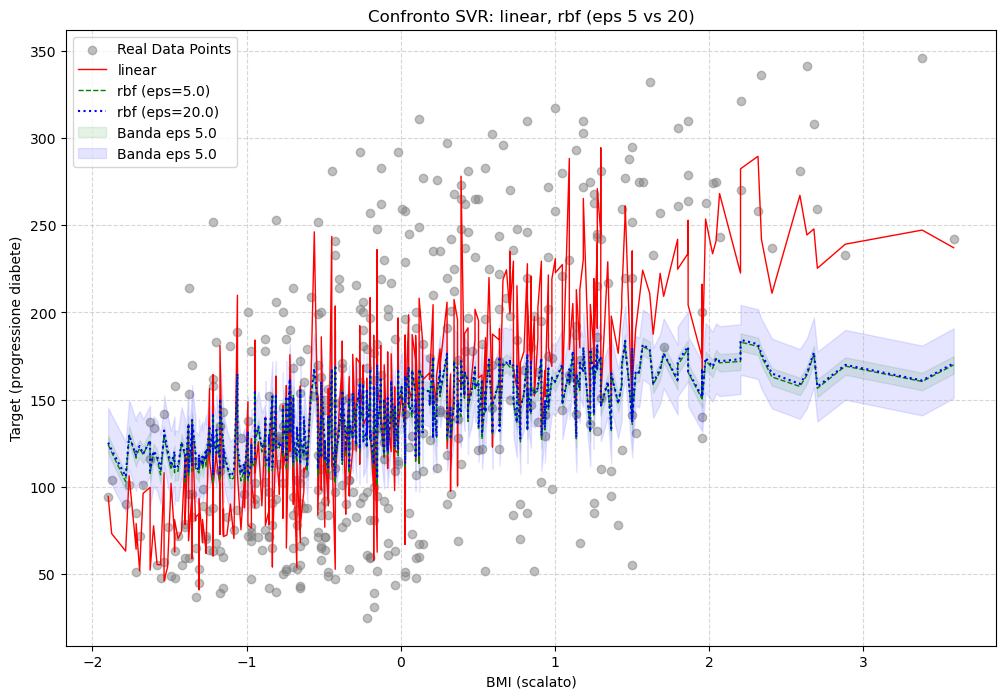

In [29]:
plt.figure(figsize=(12, 8))

plt.scatter(X_scaled[:, feature_index], y, color='gray', alpha=0.5, label="Real Data Points")

plt.plot(X_plot, y_pred_linear_plot, color='red', linestyle='-', linewidth=1, label='linear')
plt.plot(X_plot, y_pred_narrow_plot, color='green', linestyle='--', linewidth=1, label='rbf (eps=5.0)')
plt.plot(X_plot, y_pred_wide_plot, color='blue', linestyle=':', label='rbf (eps=20.0)')

plt.fill_between(X_plot, y_pred_narrow_plot - 5, y_pred_narrow_plot + 5, color='green', alpha=0.1, label='Banda eps 5.0')
plt.fill_between(X_plot, y_pred_wide_plot - 20, y_pred_wide_plot + 20, color='blue', alpha=0.1, label='Banda eps 5.0')

plt.title('Confronto SVR: linear, rbf (eps 5 vs 20)')
plt.xlabel('BMI (scalato)')
plt.ylabel('Target (progressione diabete)')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()